<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 149 &middot; Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Big Data &amp; Scaling</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Big data is not a size, it is the moment your usual approach stops working. We measure the problem first, then walk the ladder of fixes: shrink the types, stream the file in chunks, store it columnar, split the work with MapReduce written by hand, hand it to more cores, and finally meet the skew that ruins real jobs.</div>
</div>

Run top to bottom. Uses **pandas**, **numpy**, **pyarrow** (Parquet) and **joblib**. There is no cluster here on purpose: every distributed idea is demonstrated on one machine, because the concepts, not the hardware, are what you need to carry into Spark.

In [1]:
import numpy as np, pandas as pd, os, time, tempfile
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD, AM = "#a21caf", "#2563eb", "#16a34a", "#dc2626", "#d97706"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "big-data-and-scaling--ride-logs.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape)
print(df.head(3).to_string())

# A scratch folder for the larger files we build below. Nothing here is written to the book repo.
TMP = tempfile.gettempdir()
print("\nscratch folder:", TMP)

(25000, 11)
   ride_id        city vehicle_type  pickup_hour  distance_km  duration_min  surge_multiplier   fare  rider_id payment_type  rating
0        1  Metro City     standard           18         5.55          27.3               1.2  20.34      1499         card     5.0
1        2    Riverton     standard           19         1.85          11.9               1.2  10.51      1575         card     4.7
2        3  Metro City     standard           22         4.78          18.7               1.0  14.04       228       wallet     4.2

scratch folder: /var/folders/wv/rntn6xtd407cmdsyx0b0wwnw0000gn/T


## DEMO 1 &middot; Measure before you scale
The first move is never a bigger machine, it is a measurement. Ask what the data actually costs in memory, then notice how much of that cost is waste: text columns stored as Python objects and 64-bit numbers holding values that fit in 8 bits.

Converting repeated text to **category** and numbers to their smallest safe type is the cheapest speed-up in data work. Nothing about the analysis changes.

memory by column (bytes):
city            431105
vehicle_type    351212
payment_type    314548
ride_id         200000
pickup_hour     200000
distance_km     200000

before   2.70 MB
after    0.80 MB   ->  3.4x smaller, 70% saved
identical results? True


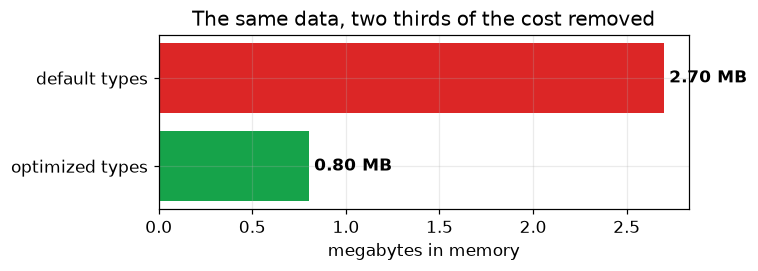

In [2]:
raw = df.memory_usage(deep=True)
print("memory by column (bytes):"); print(raw.sort_values(ascending=False).head(6).to_string())

opt = df.copy()
for col in ["city", "vehicle_type", "payment_type"]:
    opt[col] = opt[col].astype("category")          # repeated text -> integer codes + one lookup table
opt["ride_id"] = opt.ride_id.astype("int32")
opt["rider_id"] = opt.rider_id.astype("int32")
opt["pickup_hour"] = opt.pickup_hour.astype("int8")  # 0-23 needs one byte, not eight
for col in ["distance_km", "duration_min", "surge_multiplier", "fare", "rating"]:
    opt[col] = opt[col].astype("float32")

before, after = raw.sum(), opt.memory_usage(deep=True).sum()
print(f"\nbefore {before/1e6:6.2f} MB")
print(f"after  {after/1e6:6.2f} MB   ->  {before/after:.1f}x smaller, {100*(1-after/before):.0f}% saved")
print("identical results?", np.isclose(df.fare.sum(), opt.fare.sum(), rtol=1e-5))

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(["optimized types", "default types"], [after/1e6, before/1e6], color=[GR, RD])
ax.set_xlabel("megabytes in memory"); ax.set_title("The same data, two thirds of the cost removed")
for i, v in enumerate([after/1e6, before/1e6]): ax.text(v+0.03, i, f"{v:.2f} MB", va="center", fontweight="bold")
plt.tight_layout(); plt.show()

## DEMO 2 &middot; Out-of-core: process a file you never fully load
Now make the problem genuinely awkward. We write a 500,000-row version of the logs to disk, then aggregate it **without ever holding it all in memory**: read a chunk, reduce it to a small summary, throw the chunk away, repeat, then combine the summaries.

This is the single most useful big-data technique, and it is pure pandas. Note the trick in the combine step: you cannot average the chunk averages, so each chunk returns a **sum and a count** and the mean is computed at the end.

In [3]:
big = pd.concat([df]*20, ignore_index=True)
big["ride_id"] = np.arange(1, len(big)+1)
csv_path = os.path.join(TMP, "rides_big.csv")
big.to_csv(csv_path, index=False)
print(f"{len(big):,} rows | file on disk {os.path.getsize(csv_path)/1e6:.1f} MB | as a DataFrame {big.memory_usage(deep=True).sum()/1e6:.0f} MB")

t0 = time.perf_counter(); partials = []; peak_chunk = 0
for chunk in pd.read_csv(csv_path, chunksize=50_000):        # only 50k rows are in memory at a time
    peak_chunk = max(peak_chunk, chunk.memory_usage(deep=True).sum())
    partials.append(chunk.groupby("city").fare.agg(["sum", "count"]))   # reduce, then discard the chunk
streamed = pd.concat(partials).groupby(level=0).sum()
streamed["mean_fare"] = streamed["sum"] / streamed["count"]  # combine sums and counts, NOT the means
elapsed = time.perf_counter() - t0

print(f"\nstreamed in {elapsed:.2f}s holding at most {peak_chunk/1e6:.1f} MB at once")
print(streamed.sort_values("sum", ascending=False).round(2).to_string())
exact = big.groupby("city").fare.sum().sort_index()
print("\nidentical to loading the whole file?", np.allclose(streamed["sum"].sort_index(), exact))

500,000 rows | file on disk 30.2 MB | as a DataFrame 54 MB

streamed in 0.19s holding at most 5.4 MB at once
                  sum   count  mean_fare
city                                    
Metro City  3734006.4  230620      16.19
Riverton    1847063.2   94220      19.60
Lakeside    1268319.8   64180      19.76
Harborview   973586.2   49880      19.52
Fairfield    701397.0   35800      19.59
Northgate    494336.4   25300      19.54



identical to loading the whole file? True


## DEMO 3 &middot; Store it columnar: CSV versus Parquet
CSV stores data row by row as text, so reading one column means reading every byte of every row. **Parquet** stores it column by column, compressed, with statistics in the footer. Two things follow: the file shrinks, and you can read three columns out of eleven without touching the rest.

That second property, **column pruning**, is where the dramatic numbers come from. Timings will differ on your machine; the ratios are the point.

CSV      30.2 MB
Parquet   6.4 MB   ->  4.7x smaller on disk



read whole CSV         0.170s
read whole Parquet     0.007s   (24x faster)
read 2 of 11 columns   0.005s   (32x faster than the CSV)


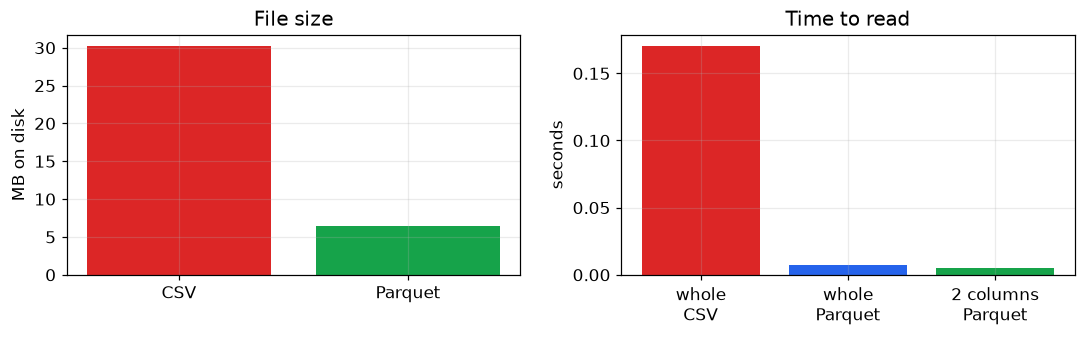

In [4]:
pq_path = os.path.join(TMP, "rides_big.parquet")
big.to_parquet(pq_path, index=False)
csv_mb, pq_mb = os.path.getsize(csv_path)/1e6, os.path.getsize(pq_path)/1e6
print(f"CSV     {csv_mb:5.1f} MB")
print(f"Parquet {pq_mb:5.1f} MB   ->  {csv_mb/pq_mb:.1f}x smaller on disk")

def best_of(fn, n=3):
    return min(( (lambda t0=time.perf_counter(): (fn(), time.perf_counter()-t0)[1])() for _ in range(n) ))
t_csv  = best_of(lambda: pd.read_csv(csv_path))
t_pq   = best_of(lambda: pd.read_parquet(pq_path))
t_cols = best_of(lambda: pd.read_parquet(pq_path, columns=["city", "fare"]))
print(f"\nread whole CSV        {t_csv:6.3f}s")
print(f"read whole Parquet    {t_pq:6.3f}s   ({t_csv/t_pq:.0f}x faster)")
print(f"read 2 of 11 columns  {t_cols:6.3f}s   ({t_csv/t_cols:.0f}x faster than the CSV)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].bar(["CSV", "Parquet"], [csv_mb, pq_mb], color=[RD, GR]); ax[0].set_ylabel("MB on disk"); ax[0].set_title("File size")
ax[1].bar(["whole\nCSV", "whole\nParquet", "2 columns\nParquet"], [t_csv, t_pq, t_cols], color=[RD, BL, GR])
ax[1].set_ylabel("seconds"); ax[1].set_title("Time to read")
plt.tight_layout(); plt.show()

## DEMO 4 &middot; MapReduce, written by hand
Every distributed engine rests on one pattern. **Map**: turn each record into a key and a value, independently, so the work can happen anywhere. **Shuffle**: gather all values that share a key onto one worker. **Reduce**: collapse each key's pile into an answer.

Below it is fifteen lines of plain Python producing exactly what a one-line pandas groupby produces. Once you can see the shuffle, you can see why it is the expensive step: it is the only part that moves data between machines.

In [5]:
from collections import defaultdict

def mapper(row):                       # 1. MAP: record -> (key, value), independent per row
    return (row.city, (row.fare, 1))

def reducer(key, values):              # 3. REDUCE: collapse one key's pile
    total = sum(v[0] for v in values); n = sum(v[1] for v in values)
    return {"revenue": total, "rides": n, "avg_fare": total/n}

pairs = [mapper(r) for r in df.itertuples()]      # MAP
shuffled = defaultdict(list)                       # SHUFFLE: group by key (the part that crosses the network)
for k, v in pairs:
    shuffled[k].append(v)
result = pd.DataFrame({k: reducer(k, v) for k, v in shuffled.items()}).T   # REDUCE

print("hand-written MapReduce:")
print(result.sort_values("revenue", ascending=False).round(2).to_string())
pandas_way = df.groupby("city").fare.agg(revenue="sum", rides="size", avg_fare="mean")
print("\nsame answer as df.groupby('city')?",
      np.allclose(result.sort_index().revenue.astype(float), pandas_way.sort_index().revenue))
print(f"records mapped: {len(pairs):,}   keys shuffled: {len(shuffled)}")

hand-written MapReduce:
              revenue    rides  avg_fare
Metro City  186700.32  11531.0     16.19
Riverton     92353.16   4711.0     19.60
Lakeside     63415.99   3209.0     19.76
Harborview   48679.31   2494.0     19.52
Fairfield    35069.85   1790.0     19.59
Northgate    24716.82   1265.0     19.54

same answer as df.groupby('city')? True
records mapped: 25,000   keys shuffled: 6


## DEMO 5 &middot; More cores, and why you never get the full speedup
Some work is **embarrassingly parallel**: split it, run the pieces anywhere, glue the results. A bootstrap is the perfect example, since every resample is independent. We run 3,200 resamples on one core, then across eight.

Watch the speedup fall well short of 8x. Splitting the work, starting workers and shipping data all cost time, and by Amdahl's law even a small serial fraction caps what more cores can ever buy you. This is the single most over-promised number in big data.

3,200 bootstrap resamples
  1 core    0.93s
  8 cores   0.36s   ->  2.6x, not 8x

bootstrap median fare = 14.76 dollars


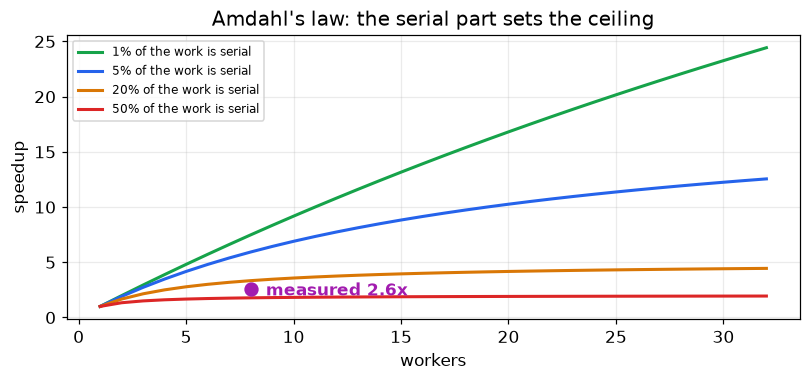

In [6]:
from joblib import Parallel, delayed
fares = df.fare.values

def boot_medians(seed, n=400):
    rng = np.random.default_rng(seed)
    return [float(np.median(rng.choice(fares, len(fares), replace=True))) for _ in range(n)]

t0 = time.perf_counter(); serial = [boot_medians(s) for s in range(8)]; t_serial = time.perf_counter()-t0
t0 = time.perf_counter(); par = Parallel(n_jobs=8)(delayed(boot_medians)(s) for s in range(8)); t_par = time.perf_counter()-t0
speedup = t_serial/t_par
print(f"3,200 bootstrap resamples")
print(f"  1 core   {t_serial:5.2f}s")
print(f"  8 cores  {t_par:5.2f}s   ->  {speedup:.1f}x, not 8x")
print(f"\nbootstrap median fare = {np.median(np.concatenate(par)):.2f} dollars")

n = np.arange(1, 33)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for s, col in [(0.01, GR), (0.05, BL), (0.20, AM), (0.50, RD)]:
    ax.plot(n, 1/(s + (1-s)/n), color=col, lw=2, label=f"{int(s*100)}% of the work is serial")
ax.scatter([8], [speedup], color=FU, zorder=5, s=70)
ax.annotate(f"measured {speedup:.1f}x", (8, speedup), textcoords="offset points", xytext=(10, -4), color=FU, fontweight="bold")
ax.set_xlabel("workers"); ax.set_ylabel("speedup"); ax.set_title("Amdahl's law: the serial part sets the ceiling"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## DEMO 6 &middot; Data skew: the straggler that ruins the job
Now the failure mode that surprises people. Partition the data by city, hand each partition to a worker, and the job takes as long as the **slowest** worker, not the average one. Our city column is deliberately lopsided, so one partition holds far more than its share.

The standard repair is **salting**: append a random suffix to the hot key so it splits across several partitions, aggregate, then combine the pieces. Watch the largest partition shrink and the estimated job time drop with it.

rows per partition (one worker each):
city
Metro City    11531
Riverton       4711
Lakeside       3209
Harborview     2494
Fairfield      1790
Northgate      1265

largest partition holds 46.1% of the rows
if every worker starts together, the job waits 2.8x the average worker

after salting the largest partition holds 11.7% of the rows
same revenue answer? True


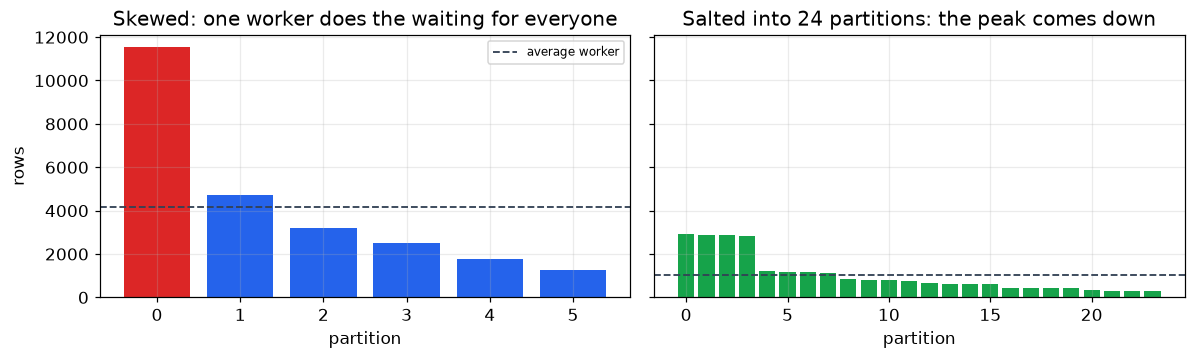

In [7]:
parts = df.city.value_counts()
print("rows per partition (one worker each):"); print(parts.to_string())
print(f"\nlargest partition holds {100*parts.max()/len(df):.1f}% of the rows")
print(f"if every worker starts together, the job waits {parts.max()/parts.mean():.1f}x the average worker")

SALT = 4
salted = (df.city + "#" + np.random.default_rng(0).integers(0, SALT, len(df)).astype(str)).rename("salt_key")
sparts = salted.value_counts()
stage1 = df.groupby(salted).fare.agg(["sum", "count"])            # stage 1: many small partitions
stage1["city"] = [k.split("#")[0] for k in stage1.index]          # strip the salt back off
final = stage1.groupby("city")[["sum", "count"]].sum()             # stage 2: combine the salted pieces
print(f"\nafter salting the largest partition holds {100*sparts.max()/len(df):.1f}% of the rows")
print("same revenue answer?", np.allclose(final["sum"].sort_index(), df.groupby("city").fare.sum().sort_index()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
ax[0].bar(range(len(parts)), parts.values, color=[RD if v == parts.max() else BL for v in parts.values])
ax[0].axhline(parts.mean(), color="#334155", ls="--", lw=1.2, label="average worker")
ax[0].set_title("Skewed: one worker does the waiting for everyone"); ax[0].set_xlabel("partition"); ax[0].set_ylabel("rows"); ax[0].legend(fontsize=8)
ax[1].bar(range(len(sparts)), sorted(sparts.values, reverse=True), color=GR)
ax[1].axhline(sparts.mean(), color="#334155", ls="--", lw=1.2)
ax[1].set_title(f"Salted into {len(sparts)} partitions: the peak comes down"); ax[1].set_xlabel("partition")
plt.tight_layout(); plt.show()

### Wrap-up
Six techniques, one machine, and not a cluster in sight. Smaller types cut the footprint by two thirds. Chunked reading aggregated 500,000 rows while holding a fraction of them. Parquet shrank the file several times over and made a two-column read almost free. Hand-written MapReduce reproduced a groupby exactly, and showed you that the shuffle is the part that costs. Eight cores bought well under eight times the speed. And a lopsided key made one worker carry nearly half the job until salting spread it out.

That is the honest shape of scaling: **measure, shrink, stream, store columnar, and only then reach for a cluster**. Spark applies these same ideas across many machines and adds fault tolerance, but if you understand chunking, partitions, shuffles and skew, you already understand what it is doing. This chapter closes Part XXIV, Advanced & Applied Topics.